In [1]:
import numpy as np
import pandas as pd

# 设置随机种子
np.random.seed(42)

# 生成200个样本
n_samples = 400

# 生成特征
# 1. 房屋面积 (平方米)
area = np.random.uniform(50, 200, n_samples)

# 2. 卧室数量
bedrooms = np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.1, 0.3, 0.4, 0.15, 0.05])

# 3. 房龄 (年)
age = np.random.exponential(10, n_samples)
age = np.clip(age, 0, 50)  # 限制在0-50年

# 4. 地理位置评分 (1-10分)
location = np.random.normal(6, 2, n_samples)
location = np.clip(location, 1, 10)

# 生成目标变量：房价 (万元)
# 真实关系：price = 0.8*area + 15*bedrooms - 0.5*age + 8*location + 30 + noise
noise = np.random.normal(0, 20, n_samples)
price = 0.8 * area + 15 * bedrooms - 0.5 * age + 8 * location + 30 + noise

# 创建DataFrame
data = pd.DataFrame({
    'area': area,
    'bedrooms': bedrooms,
    'age': age,
    'location': location,
    'price': price
})


In [2]:
data_train=data.sample(frac=0.67)
data_test=data.sample(frac=0.33)

In [3]:
import numpy as np
import pandas as pd

# 正确的数据标准化
def normalize_data(data):
    return (data - data.mean()) / data.std()

# 标准化训练数据
data_normalized = data_train.copy()
for col in data_normalized.columns:
    data_normalized[col] = normalize_data(data_normalized[col])

# 同样标准化测试数据
data_test_normalized = data_test.copy()
for col in data_test_normalized.columns:
    data_test_normalized[col] = normalize_data(data_test_normalized[col])

# 重新初始化参数 - 使用更合理的范围
rng = np.random.default_rng(17)
primary_parameter = {
    'power1': rng.standard_normal((4, 7)) * 0.1,  # 缩小初始权重
    'bias1': np.zeros(7),  # 改为bias而不是threshold
    'power2': rng.standard_normal((7, 1)) * 0.1,
    'bias2': np.zeros(1)
}

def sigmoid(x):
    return 1/(1+np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def get_loss(y, y_hat):
    return 0.5 * np.mean((y_hat - y)**2)

def forward_pass(x, parameters):
    """前向传播"""
    # 输入到隐藏层
    z1 = x @ parameters['power1'] + parameters['bias1']
    a1 = relu(z1)  # 使用ReLU替代sigmoid
    
    # 隐藏层到输出层 - 线性激活用于回归
    z2 = a1 @ parameters['power2'] + parameters['bias2']
    return z2, a1  # 直接输出，不使用sigmoid

def backward_pass(x, y, y_hat, a1, parameters, learning_rate=0.01):
    """反向传播"""
    # 输出层梯度 - 由于是线性输出，导数为1
    d_z2 = (y_hat - y)  # shape: (1,)
    
    # 隐藏层梯度
    d_a1 = d_z2 * parameters['power2'].T  # (1,7)
    d_z1 = d_a1 * (a1 > 0)  # ReLU的导数
    
    # 更新参数
    parameters['power2'] -= learning_rate * a1.reshape(-1, 1) @ d_z2.reshape(1, -1)
    parameters['bias2'] -= learning_rate * d_z2
    parameters['power1'] -= learning_rate * x.reshape(-1, 1) @ d_z1
    parameters['bias1'] -= learning_rate * d_z1.flatten()
    
    return parameters

def train_epoch(data, parameters, epoch):
    """训练一个epoch"""
    total_loss = 0
    for i in range(len(data)):
        row = data.iloc[i]
        x = row[['area', 'bedrooms', 'age', 'location']].values
        y = row['price']
        
        # 前向传播
        y_hat, a1 = forward_pass(x, parameters)
        
        # 计算损失
        loss = get_loss(y, y_hat)
        total_loss += loss
        
        # 反向传播
        parameters = backward_pass(x, y, y_hat, a1, parameters, learning_rate=0.001)
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Average Loss: {total_loss/len(data):.6f}")
    
    return parameters

# 训练网络
for epoch in range(100):
    primary_parameter = train_epoch(data_normalized, primary_parameter, epoch)

print("训练完成！")

Epoch 0, Average Loss: 0.511834
Epoch 20, Average Loss: 0.151870
Epoch 40, Average Loss: 0.103260
Epoch 60, Average Loss: 0.089245
Epoch 80, Average Loss: 0.085417
训练完成！


In [4]:
def predict(x, parameters):
    y_hat, _ = forward_pass(x, parameters)
    return y_hat

# 在测试集上评估
test_predictions = []
test_actual = []

for i in range(len(data_test_normalized)):
    row = data_test_normalized.iloc[i]
    x = row[['area', 'bedrooms', 'age', 'location']].values
    y = row['price']
    
    y_hat = predict(x, primary_parameter)
    test_predictions.append(y_hat[0])
    test_actual.append(y)

# 反标准化得到真实价格
price_mean = data_train['price'].mean()
price_std = data_train['price'].std()

test_predictions_real = np.array(test_predictions) * price_std + price_mean
test_actual_real = np.array(test_actual) * price_std + price_mean

print(f"预测价格范围: {test_predictions_real.min():.1f} - {test_predictions_real.max():.1f}")
print(f"真实价格范围: {test_actual_real.min():.1f} - {test_actual_real.max():.1f}")
print(f"测试集MSE: {np.mean((test_predictions_real - test_actual_real)**2):.2f}")

预测价格范围: 120.4 - 298.0
真实价格范围: 122.2 - 325.9
测试集MSE: 366.06


In [5]:
compair=pd.DataFrame({'test_actual':test_actual_real,'test_prediction':test_predictions_real})
compair.head()

,test_actual,test_prediction
0,153.434822,162.001878
1,192.768836,206.867982
2,164.652016,217.066427
3,234.718550,242.652022
4,177.628626,177.735429


In [6]:
import matplotlib.pyplot as plt
%matplotlib inline


<Axes: xlabel='test_actual', ylabel='test_prediction'>

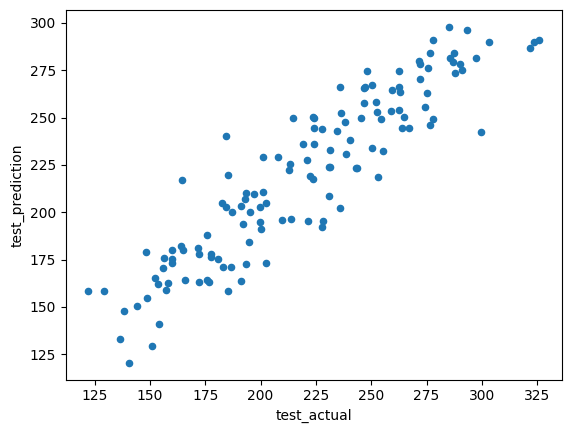

In [9]:
compair.plot(kind='scatter',x='test_actual',y='test_prediction')